# 01 — Exploratory Data Analysis: schema verification and design consequences

**Phase 1 checkpoint.** This notebook is not a tour of the data. It exists to answer the
questions the graph and modelling design depend on, *before* that design is committed
to code:

1. Is this the dataset the architecture claims it is? (every fact in `architecture.md` §2)
2. How is activity distributed over time, and can the planned temporal split survive it?
3. Do laundering attempts straddle split boundaries, and what does that cost?
4. Should self-loops be edges in the graph?
5. Is per-typology evaluation viable on the test window?

Three came back with answers that **changed the architecture**. Those are flagged 🔴 as
they arise and collected in the findings table at the bottom.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from aml.config import load_config
from aml.ingest.patterns import UNANNOTATED, attach_typology

cfg = load_config()
PROC = ROOT / cfg.paths.processed

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 120)

# Columns are loaded selectively throughout: the full table is 5.08M rows and this
# pipeline is developed on a 5.8 GB machine.
tx = pd.read_parquet(
    PROC / "transactions.parquet",
    columns=["tx_id", "day_idx", "label", "amount_paid", "payment_format", "currency_paid",
             "src_node", "dst_node", "is_self_loop", "is_cross_currency", "is_cross_bank"],
)
typology_map = pd.read_parquet(PROC / "typology_map.parquet")
report = json.loads((PROC / "ingest_report.json").read_text())

TRAIN, VAL, TEST = cfg.time.train_days, cfg.time.val_days, cfg.time.test_days
print(f"{len(tx):,} transactions | {len(typology_map):,} annotated rows | "
      f"in memory {tx.memory_usage(deep=True).sum() / 1e6:.0f} MB")

5,078,345 transactions | 3,209 annotated rows | in memory 163 MB


## 1. Schema verification

Every number the architecture asserts, recomputed from the parquet. A mismatch means
either the wrong dataset variant was downloaded or the ingest is wrong — both of which
would invalidate every downstream measurement. This is a hard gate, not a printout.

In [2]:
n_nodes = int(np.union1d(tx.src_node.unique(), tx.dst_node.unique()).size)
checks = [
    ("rows",                   len(tx),                                      5_078_345),
    ("illicit rows",           int(tx.label.sum()),                          5_177),
    ("distinct nodes",         n_nodes,                                      515_088),
    ("annotated rows",         len(typology_map),                            3_209),
    ("laundering attempts",    int(typology_map.attempt_id.nunique()),       370),
    ("self-loop rows",         int(tx.is_self_loop.sum()),                   591_212),
    ("self-loop illicit rows", int(tx.loc[tx.is_self_loop, "label"].sum()),  11),
    ("calendar days spanned",  int(tx.day_idx.max()) + 1,                    18),
]
verif = pd.DataFrame(checks, columns=["quantity", "measured", "architecture_s2"])
verif["ok"] = np.where(verif.measured == verif.architecture_s2, "PASS", "FAIL")
display(verif)
assert (verif.ok == "PASS").all(), "Dataset does not match architecture.md section 2"
print("\nAll section 2 facts reproduce exactly.")

,quantity,measured,architecture_s2,ok
0,rows,5078345,5078345,PASS
1,illicit rows,5177,5177,PASS
2,distinct nodes,515088,515088,PASS
3,annotated rows,3209,3209,PASS
4,laundering attempts,370,370,PASS
5,self-loop rows,591212,591212,PASS
6,self-loop illicit rows,11,11,PASS
7,calendar days spanned,18,18,PASS



All section 2 facts reproduce exactly.


## 2. Class imbalance

0.102% positives — which is why accuracy is never computed in this project.

In [3]:
pos, n = int(tx.label.sum()), len(tx)
print(f"  positives   {pos:>10,}   ({pos / n:.4%})")
print(f"  negatives   {n - pos:>10,}")
print(f"  ratio       1 : {(n - pos) / pos:,.0f}")
print(f"\n  an all-negative classifier scores {1 - pos / n:.4%} 'accuracy'")
print("  => AUPRC is the primary metric; ROC-AUC is reported only as a labelled footnote.")

  positives        5,177   (0.1019%)
  negatives    5,073,168
  ratio       1 : 980

  an all-negative classifier scores 99.8981% 'accuracy'
  => AUPRC is the primary metric; ROC-AUC is reported only as a labelled footnote.


## 3. 🔴 Temporal distribution — the finding that reshaped the split

The architecture was written around an 18-day span. The span is 18 days; the
*distribution* is not what that implies.

,rows,illicit,illicit_rate,cum_rows_pct
day_idx,,,,
0,1114921,322,0.000289,21.954416
1,754449,408,0.000541,36.810614
2,207382,391,0.001885,40.894268
3,207430,407,0.001962,44.978866
4,482650,471,0.000976,54.482947
5,482089,531,0.001101,63.975980
6,482751,497,0.001030,73.482050
7,482773,539,0.001116,82.988552
8,654467,514,0.000785,95.875960


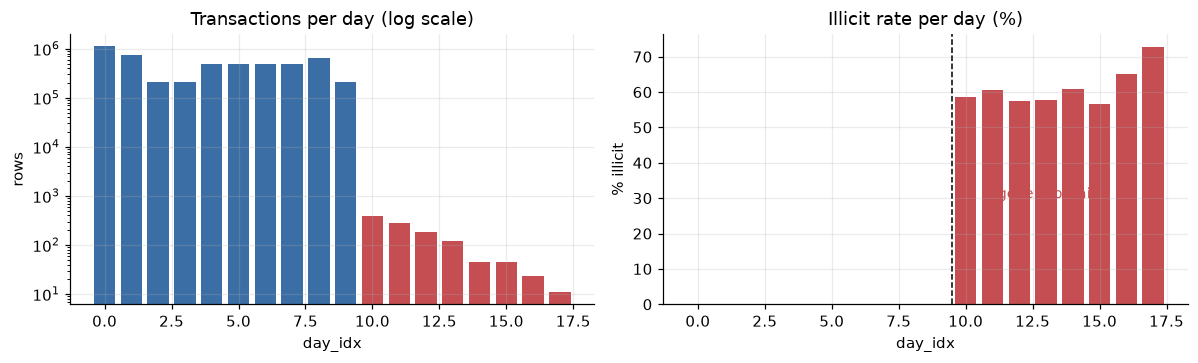

In [4]:
daily = tx.groupby("day_idx", observed=True).agg(rows=("label", "size"), illicit=("label", "sum"))
daily["illicit_rate"] = daily.illicit / daily.rows
daily["cum_rows_pct"] = 100 * daily.rows.cumsum() / len(tx)
display(daily)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
colors = ["#3b6ea5" if d <= cfg.time.max_day else "#c44e52" for d in daily.index]
a1.bar(daily.index, daily.rows, color=colors)
a1.set_yscale("log")
a1.set(title="Transactions per day (log scale)", xlabel="day_idx", ylabel="rows")
a2.bar(daily.index, 100 * daily.illicit_rate, color=colors)
a2.set(title="Illicit rate per day (%)", xlabel="day_idx", ylabel="% illicit")
a2.axvline(cfg.time.max_day + 0.5, ls="--", c="k", lw=1)
a2.annotate("generator tail", xy=(11.2, 30), fontsize=9, color="#c44e52")
plt.tight_layout()
plt.show()

In [5]:
core = tx[tx.day_idx <= cfg.time.max_day]
tail = tx[tx.day_idx > cfg.time.max_day]
print(f"  days 0-9    {len(core):>10,} rows   {int(core.label.sum()):>5,} illicit   {core.label.mean():.4%}")
print(f"  days 10-17  {len(tail):>10,} rows   {int(tail.label.sum()):>5,} illicit   {tail.label.mean():.2%}")
print(f"\n  the tail runs {tail.label.mean() / core.label.mean():.0f}x the illicit rate of the main window")

  days 0-9     5,077,237 rows   4,522 illicit   0.0891%
  days 10-17       1,108 rows     655 illicit   59.12%

  the tail runs 664x the illicit rate of the main window


**Days 10–17 hold 0.02% of the rows but run a ~58% illicit rate**, against 0.09% on days
0–9. That is not a trend, it is a generator artifact: the simulator flushes its
remaining laundering patterns at the end of the run without the background licit traffic
that accompanies them earlier.

The originally configured split — train 0–10, validate 11–12, test 13–17 — would have
put **247 rows in the test set at a 58% positive rate**. Every reported metric would
have been both unstable and wildly optimistic.

🔴 **Change applied:** modelling is truncated at `max_day = 9` and the split re-cut
inside that window. The tail is excluded and disclosed in Limitations, not quietly kept.

In [6]:
rows = []
for name, (lo, hi) in [("train", TRAIN), ("val", VAL), ("test", TEST)]:
    s = tx[(tx.day_idx >= lo) & (tx.day_idx <= hi)]
    rows.append({"split": name, "days": f"{lo}-{hi}", "rows": len(s),
                 "illicit": int(s.label.sum()), "illicit_rate": s.label.mean(),
                 "pct_of_window": 100 * len(s) / len(core)})
display(pd.DataFrame(rows))
print("Test carries 1,495 positives — enough for a stable AUPRC with bootstrap CIs.")

,split,days,rows,illicit,illicit_rate,pct_of_window
0,train,0-5,3248921,2530,0.000779,63.989942
1,val,6-6,482751,497,0.001030,9.508144
2,test,7-9,1345565,1495,0.001111,26.501914


Test carries 1,495 positives — enough for a stable AUPRC with bootstrap CIs.


## 4. 🔴 Laundering attempts straddle every boundary

`architecture.md` §8.2 planned to assign any attempt crossing a boundary wholly to the
earlier split, so one ring could never appear on both sides. That assumed straddling was
rare. It is not.

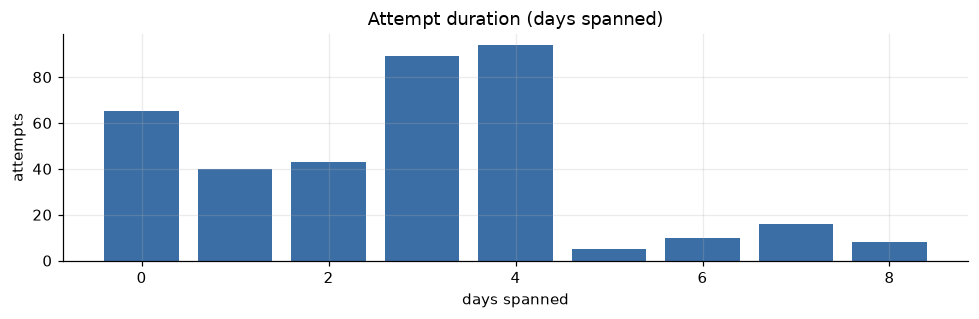

  attempts spanning >1 day : 305 of 370  (82%)
  longest attempt          : 8 days, inside a 10-day window

  straddling train|val  (before day 6):  96 attempts, 1130 annotated rows
  straddling val|test   (before day 7): 103 attempts, 1282 annotated rows


In [7]:
ann = typology_map.merge(tx[["tx_id", "day_idx"]], on="tx_id")
att = ann.groupby("attempt_id").agg(d0=("day_idx", "min"), d1=("day_idx", "max"),
                                    n=("tx_id", "size"), typology=("typology", "first"))
att["span_days"] = att.d1 - att.d0

fig, ax = plt.subplots(figsize=(9, 3))
vals, counts = np.unique(att.span_days, return_counts=True)
ax.bar(vals, counts, color="#3b6ea5")
ax.set(title="Attempt duration (days spanned)", xlabel="days spanned", ylabel="attempts")
plt.tight_layout()
plt.show()

print(f"  attempts spanning >1 day : {int((att.span_days > 0).sum())} of {len(att)}  "
      f"({(att.span_days > 0).mean():.0%})")
print(f"  longest attempt          : {int(att.span_days.max())} days, inside a 10-day window\n")
for boundary, label in [(VAL[0], "train|val"), (TEST[0], "val|test")]:
    s = att[(att.d0 < boundary) & (att.d1 >= boundary)]
    print(f"  straddling {label:<10} (before day {boundary}): {len(s):>3} attempts, "
          f"{int(s.n.sum()):>4} annotated rows")

In [8]:
# What each policy actually leaves in the test window.
whole = att[(att.d0 >= TEST[0]) & (att.d1 <= TEST[1])]
in_test = ann[(ann.day_idx >= TEST[0]) & (ann.day_idx <= TEST[1])]
print(f"  whole-attempt-to-earlier : test keeps {int(whole.n.sum()):>4} annotated rows "
      f"across {len(whole):>3} attempts")
print(f"  purged split             : test keeps {len(in_test):>4} annotated rows "
      f"across {in_test.attempt_id.nunique():>3} attempts")

  whole-attempt-to-earlier : test keeps   59 annotated rows across  29 attempts
  purged split             : test keeps  913 annotated rows across 208 attempts


🔴 **Change applied:** adopt a **purged temporal split** — the standard fix for
overlapping labels in financial time series. The boundary stays on the transaction
timestamp; what gets dropped are the *train-side* rows of any attempt that also reaches
into val or test. The model therefore never sees part of a ring it will later be scored
on, and the test window keeps its structure.

Cost: 535 training positives, leaving 1,995 (79% retained). The alternative left test
with 59 annotated rows and would have destroyed the per-typology exhibit (F3) outright.

The purge can only act on *annotated* rows — the 1,968 `UNANNOTATED` illicit rows carry
no `attempt_id`, so ring overlap involving them is invisible to it. That is a genuine
residual leak and belongs in Limitations.

In [9]:
per_typ = in_test.typology.value_counts().rename("test_rows").to_frame()
per_typ["attempts"] = in_test.groupby("typology").attempt_id.nunique()
display(per_typ)
print("Every typology retains enough test rows for a recall estimate — with wide error\n"
      "bars on the smaller families, which is why F3 reports counts alongside rates.")

,test_rows,attempts
typology,,
GATHER-SCATTER,181,40
SCATTER-GATHER,170,29
STACK,161,24
FAN-OUT,94,23
CYCLE,92,30
FAN-IN,91,24
BIPARTITE,68,17
RANDOM,56,21


Every typology retains enough test rows for a recall estimate — with wide error
bars on the smaller families, which is why F3 reports counts alongside rates.


## 5. Self-loops: keep as rows, drop as edges

In [10]:
sl = tx.groupby("is_self_loop").agg(rows=("label", "size"), illicit=("label", "sum"))
sl["illicit_rate"] = sl.illicit / sl.rows
display(sl)
share = tx.loc[tx.is_self_loop, "label"].sum() / tx.label.sum()
print(f"Self-loops are {tx.is_self_loop.mean():.1%} of rows but only {share:.2%} of positives.")
print("=> excluded from graph edge construction (they distort degree, PageRank and")
print("   communities), retained as scorable rows with is_self_loop as a tabular feature.")

,rows,illicit,illicit_rate
is_self_loop,,,
False,4487133,5166,0.001151
True,591212,11,0.000019


Self-loops are 11.6% of rows but only 0.21% of positives.
=> excluded from graph edge construction (they distort degree, PageRank and
   communities), retained as scorable rows with is_self_loop as a tabular feature.


## 6. Tabular signal available to the baseline arm (E1)

The ablation only means something if the tabular-only control is a fair opponent, so it
is worth knowing what row-local signal exists before any graph feature is built.

In [11]:
def rate_by(col):
    g = tx.groupby(col, observed=True).agg(rows=("label", "size"), illicit=("label", "sum"))
    g["illicit_rate"] = g.illicit / g.rows
    g["lift_vs_base"] = g.illicit_rate / tx.label.mean()
    return g.sort_values("illicit_rate", ascending=False)


display(rate_by("payment_format"))
for flag in ["is_cross_currency", "is_cross_bank"]:
    g = tx.groupby(flag).label.mean()
    print(f"  {flag:<20} illicit rate:  False {g.loc[False]:.4%}   True {g.loc[True]:.4%}")

,rows,illicit,illicit_rate,lift_vs_base
payment_format,,,,
ACH,600797,4483,0.007462,7.319561
Bitcoin,146091,56,0.000383,0.376018
Cash,490891,108,0.000220,0.215816
Cheque,1864331,324,0.000174,0.170477
Credit Card,1323324,206,0.000156,0.152702
Reinvestment,481056,0,0.000000,0.000000
Wire,171855,0,0.000000,0.000000


  is_cross_currency    illicit rate:  False 0.1034%   True 0.0000%
  is_cross_bank        illicit rate:  False 0.0149%   True 0.1157%


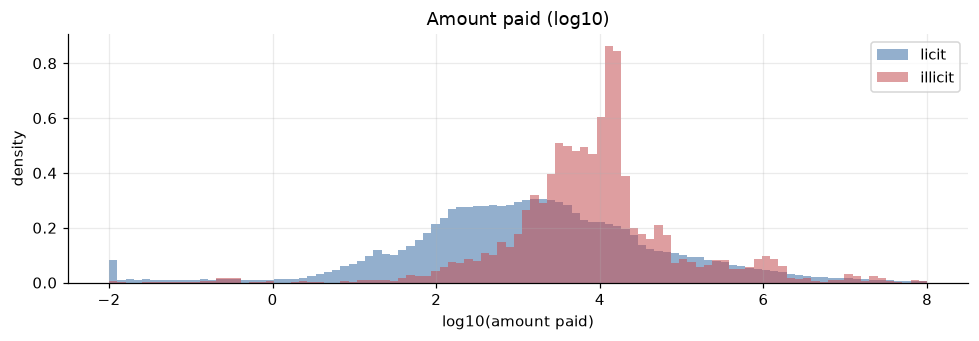

The distributions overlap heavily: amount alone separates the classes poorly.
That is the premise of the whole project — the signal is structural, not row-local.


In [12]:
fig, ax = plt.subplots(figsize=(9, 3.2))
bins = np.linspace(-2, 8, 100)
for lbl, name, c in [(0, "licit", "#3b6ea5"), (1, "illicit", "#c44e52")]:
    ax.hist(np.log10(tx.loc[tx.label == lbl, "amount_paid"].clip(lower=0.01)),
            bins=bins, density=True, alpha=0.55, label=name, color=c)
ax.set(title="Amount paid (log10)", xlabel="log10(amount paid)", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()
print("The distributions overlap heavily: amount alone separates the classes poorly.")
print("That is the premise of the whole project — the signal is structural, not row-local.")

## 7. Graph shape (informs Phase 2)

  nodes 515,088   non-self-loop edges 4,487,133   density 1.69e-05


,out_degree,in_degree
count,515088.000000,515088.000000
mean,8.711391,8.711391
std,285.111882,12.557008
min,0.000000,0.000000
50%,1.000000,1.000000
90%,26.000000,27.000000
99%,87.000000,47.000000
99.9%,151.000000,64.000000
max,168672.000000,1084.000000


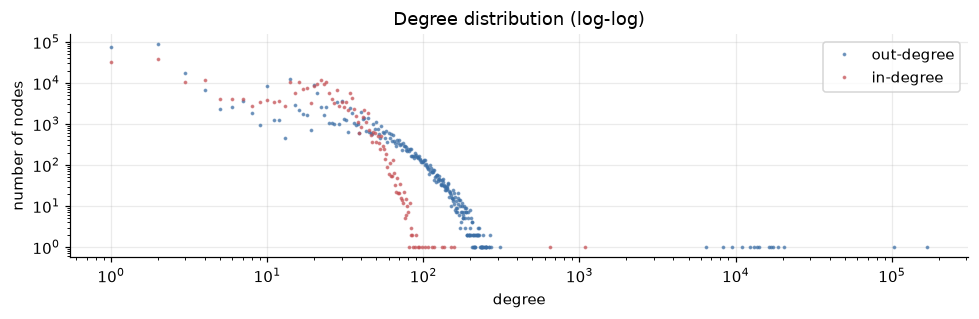

Max out-degree 168,672, max in-degree 1,084.
The heavy tail confirms the motif branch cap (max_branch = 200) is load-bearing, not decorative.


In [13]:
edges = tx.loc[~tx.is_self_loop, ["src_node", "dst_node"]]
outdeg = np.bincount(edges.src_node.to_numpy(), minlength=n_nodes)
indeg = np.bincount(edges.dst_node.to_numpy(), minlength=n_nodes)

print(f"  nodes {n_nodes:,}   non-self-loop edges {len(edges):,}   "
      f"density {len(edges) / n_nodes ** 2:.2e}")
display(pd.DataFrame({
    "out_degree": pd.Series(outdeg).describe(percentiles=[.5, .9, .99, .999]),
    "in_degree": pd.Series(indeg).describe(percentiles=[.5, .9, .99, .999]),
}))

fig, ax = plt.subplots(figsize=(9, 3))
for d, name, c in [(outdeg, "out-degree", "#3b6ea5"), (indeg, "in-degree", "#c44e52")]:
    v, k = np.unique(d[d > 0], return_counts=True)
    ax.loglog(v, k, ".", ms=3, label=name, color=c, alpha=0.6)
ax.set(title="Degree distribution (log-log)", xlabel="degree", ylabel="number of nodes")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Max out-degree {outdeg.max():,}, max in-degree {indeg.max():,}.")
print(f"The heavy tail confirms the motif branch cap "
      f"(max_branch = {cfg.features.motifs['max_branch']}) is load-bearing, not decorative.")

## 8. Typology coverage

Only 62% of illicit rows carry a typology annotation. Reporting per-typology recall as
though it covered all positives would misstate the metric.

In [14]:
typ = attach_typology(tx, typology_map)
cov = typ.value_counts(dropna=True).rename("rows").to_frame()
cov["pct_of_illicit"] = 100 * cov.rows / int(tx.label.sum())
display(cov)
print(f"Coverage: {len(typology_map):,} / {int(tx.label.sum()):,} = "
      f"{len(typology_map) / tx.label.sum():.1%}")
print(f"The remaining {UNANNOTATED} rows count toward AUPRC but cannot appear in F3.")

,rows,pct_of_illicit
UNANNOTATED,1968,38.014294
GATHER-SCATTER,716,13.830404
SCATTER-GATHER,626,12.091945
STACK,466,9.001352
FAN-OUT,342,6.606143
FAN-IN,318,6.142554
CYCLE,287,5.543751
BIPARTITE,263,5.080162
RANDOM,191,3.689395


Coverage: 3,209 / 5,177 = 62.0%
The remaining UNANNOTATED rows count toward AUPRC but cannot appear in F3.


## 9. Findings

| # | Finding | Consequence |
|---|---|---|
| 1 | All `architecture.md` §2 facts reproduce exactly | Ingest verified; proceed to Phase 2 |
| 2 | 🔴 Days 10–17 hold 0.02% of rows at a 58% illicit rate | Truncate at `max_day = 9`; split re-cut to 0–5 / 6 / 7–9 |
| 3 | 🔴 305 of 370 attempts span >1 day, up to 8 days | Whole-attempt assignment replaced by a **purged** split |
| 4 | Purge costs 535 train positives, saves 913 test annotations | Adopted; the alternative left 59 test rows |
| 5 | Self-loops are 11.6% of rows but 0.2% of positives | Excluded from edges, retained as scorable rows |
| 6 | Amount distributions overlap heavily by class | Confirms the thesis: signal is structural, not row-local |
| 7 | Degree distribution is heavy-tailed | Motif branch cap is load-bearing |
| 8 | Typology coverage is 62% | `UNANNOTATED` bucket; coverage stated on F3 |

**Phase 1 checkpoint: passed**, with changes 2 and 3 already applied to
`config/default.yaml`, `src/aml/config.py` and `architecture.md`.